In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(project="focus-appliance-507309-h8")

df = client.query("""
    select * from `dbt_dev.stg_telco__demographics`
""").to_dataframe()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customer_id           7043 non-null   str    
 1   gender                7043 non-null   str    
 2   age                   7043 non-null   Int64  
 3   married               7043 non-null   boolean
 4   number_of_dependents  7043 non-null   Int64  
dtypes: Int64(2), boolean(1), str(2)
memory usage: 350.8 KB


## Profilling

### Demographics

In [5]:
query = """
SELECT
    *
FROM `dbt_dev.stg_telco__demographics`
"""

demo_df = client.query(query).to_dataframe()
demo_df

,customer_id,gender,age,married,number_of_dependents
0,7841-tzdmq,male,19,False,0
1,0822-gavap,female,19,False,0
2,5673-fssmf,female,19,False,0
3,4704-eryfc,female,19,True,0
4,4763-pgdpo,female,19,False,0
...,...,...,...,...,...
7038,4323-sadqs,male,61,True,6
7039,5510-boiuj,male,35,False,7
7040,6286-zhaok,female,47,True,7
7041,6950-twmyb,male,31,True,8


In [6]:
demo_df.describe()

,age,number_of_dependents
count,7043.0,7043.0
mean,46.509726,0.468692
std,16.750352,0.962802
min,19.0,0.0
25%,32.0,0.0
50%,46.0,0.0
75%,60.0,0.0
max,80.0,9.0


<Axes: xlabel='age'>

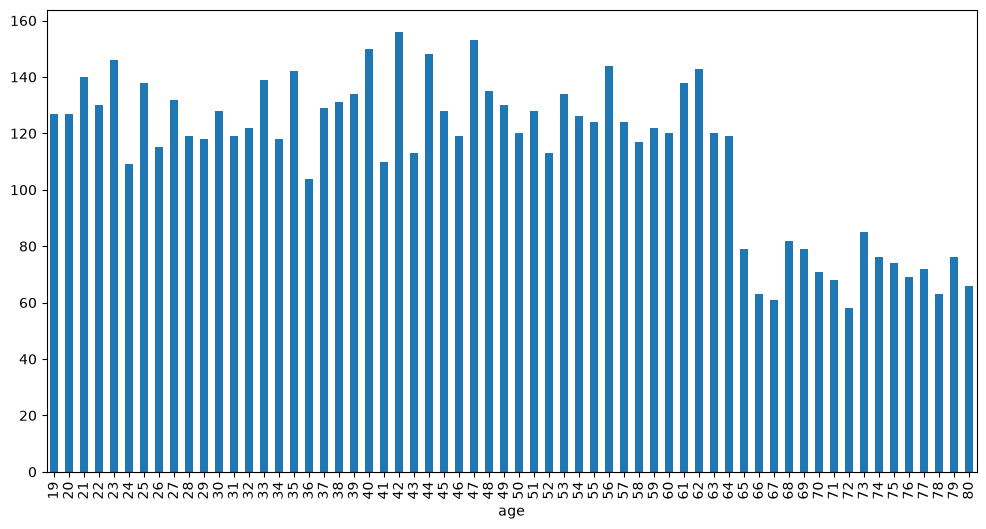

In [7]:
demo_df['age'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))

<Axes: xlabel='number_of_dependents'>

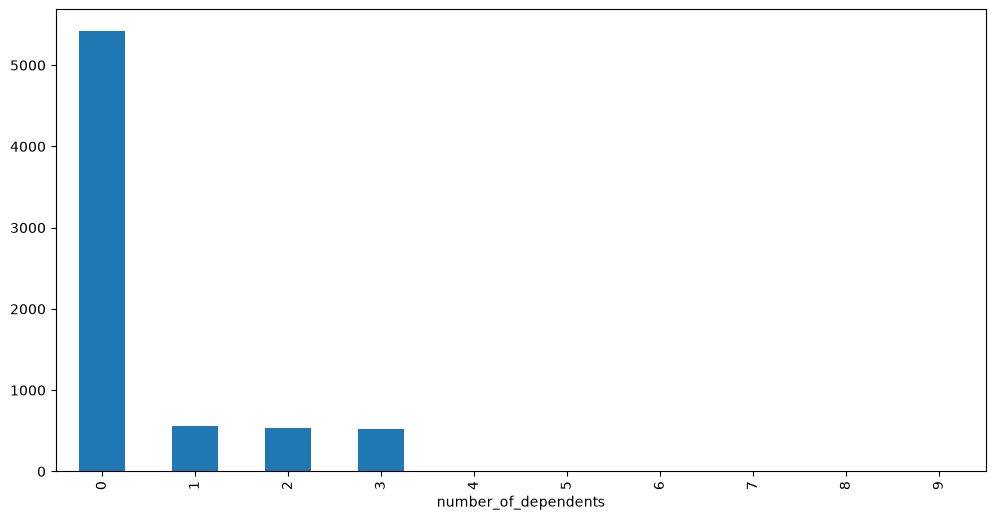

In [8]:
demo_df['number_of_dependents'].value_counts().sort_index().plot(kind='bar', figsize=(12, 6))

In [9]:
def profile(df):
    """Dtype, null count and distinct count for every column."""
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulls": df.isna().sum(),
        "null_pct": (df.isna().mean() * 100).round(2),
        "distinct": df.nunique(dropna=True),
    })


def load(model):
    """Pull a staging model into a dataframe."""
    return client.query(f"select * from `dbt_dev.{model}`").to_dataframe()

In [10]:
profile(demo_df)

,dtype,nulls,null_pct,distinct
customer_id,str,0,0.0,7043
gender,str,0,0.0,2
age,Int64,0,0.0,62
married,boolean,0,0.0,2
number_of_dependents,Int64,0,0.0,10


In [15]:
# grain: one row per customer_id
print("rows:", len(demo_df), "| unique customer_id:", demo_df["customer_id"].nunique())

print(demo_df["married"].value_counts())
demo_df["gender"].value_counts()

rows: 7043 | unique customer_id: 7043
married
False    3641
True     3402
Name: count, dtype: Int64


gender
male      3555
female    3488
Name: count, dtype: int64

### Location

In [16]:
loc_df = load("stg_telco__location")
loc_df.head()

,customer_id,country,state,city,zip_code,latitude,longitude
0,8844-tonud,united states,california,acampo,95220,38.200231,-121.235034
1,1455-ugqvh,united states,california,acampo,95220,38.200231,-121.235034
2,9249-fxsck,united states,california,acampo,95220,38.200231,-121.235034
3,1017-fbqmm,united states,california,acampo,95220,38.200231,-121.235034
4,4083-bfnyk,united states,california,acton,93510,34.501452,-118.207862


In [17]:
profile(loc_df)

,dtype,nulls,null_pct,distinct
customer_id,str,0,0.0,7043
country,str,0,0.0,1
state,str,0,0.0,1
city,str,0,0.0,1106
zip_code,str,0,0.0,1626
latitude,float64,0,0.0,1626
longitude,float64,0,0.0,1625


In [ ]:
# grain: one row per customer_id; country and state should be constants
print("rows:", len(loc_df), "| unique customer_id:", loc_df["customer_id"].nunique())
print(loc_df["country"].unique(), loc_df["state"].unique());

rows: 7043 | unique customer_id: 7043
<ArrowStringArray>
['united states']
Length: 1, dtype: str <ArrowStringArray>
['california']
Length: 1, dtype: str


In [ ]:
# does zip_code behave as a location key? expect 1 city / lat / long per zip
loc_df.groupby("zip_code")[["city", "latitude", "longitude"]].nunique().max();

city         1
latitude     1
longitude    1
dtype: int64

<Axes: title={'center': 'customers per city (top 15)'}, ylabel='city'>

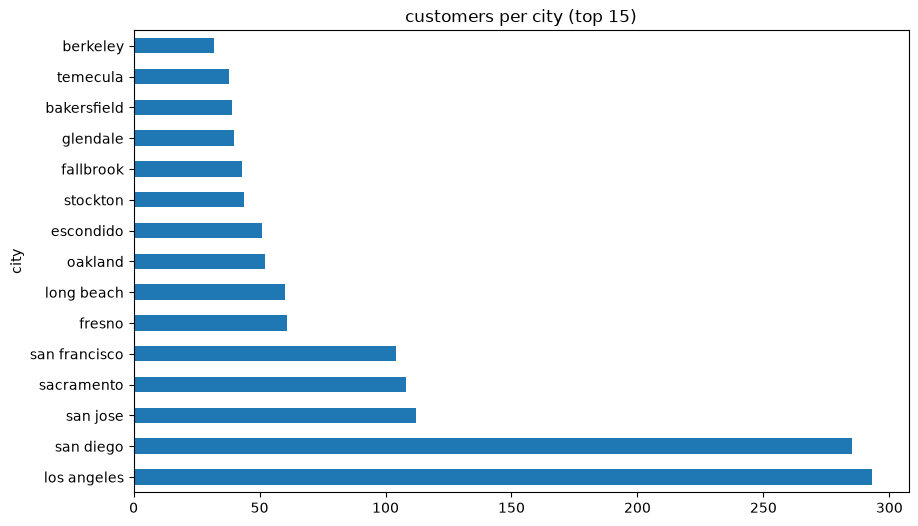

In [ ]:
loc_df["city"].value_counts().head(15).plot(kind="barh", figsize=(10, 6), title="customers per city (top 15)");

### Population

In [21]:
pop_df = load("stg_telco__population")
profile(pop_df)

,dtype,nulls,null_pct,distinct
zip_code,str,0,0.0,1671
population,Int64,0,0.0,1607


In [22]:
# grain: one row per zip_code, and every customer zip should be covered
print("rows:", len(pop_df), "| unique zip_code:", pop_df["zip_code"].nunique())

customer_zips = set(loc_df["zip_code"])
population_zips = set(pop_df["zip_code"])
print("customer zips missing from population:", len(customer_zips - population_zips))
print("population zips with no customer:", len(population_zips - customer_zips))

rows: 1671 | unique zip_code: 1671
customer zips missing from population: 0
population zips with no customer: 45


<Axes: title={'center': 'population per zip_code'}, ylabel='Frequency'>

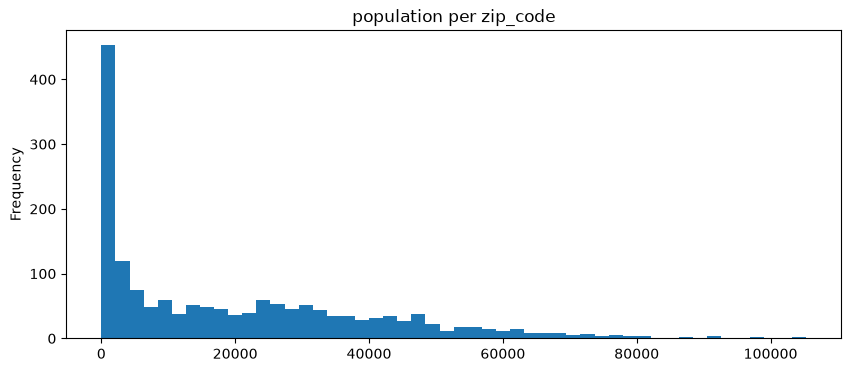

In [23]:
pop_df["population"].plot(kind="hist", bins=50, figsize=(10, 4), title="population per zip_code")

### Services

In [24]:
svc_df = load("stg_telco__services")
profile(svc_df)

,dtype,nulls,null_pct,distinct
customer_id,str,0,0.0,7043
referred_a_friend,boolean,0,0.0,2
number_of_referrals,Int64,0,0.0,12
tenure_in_months,Int64,0,0.0,72
offer,str,0,0.0,6
phone_service,boolean,0,0.0,2
avg_monthly_long_distance_charges,float64,0,0.0,3584
multiple_lines,boolean,0,0.0,2
internet_service,boolean,0,0.0,2
internet_type,str,0,0.0,4


In [47]:
categorical = ["offer", "internet_type", "contract", "payment_method"]

for col in categorical:
    print(svc_df[col].value_counts(dropna=False, normalize=True)*100, "\n")

offer
none       55.047565
offer b    11.699560
offer e    11.429788
offer d     8.547494
offer a     7.383217
offer c     5.892375
Name: proportion, dtype: float64 

internet_type
fiber optic    43.092432
dsl            23.455914
none           21.666903
cable          11.784751
Name: proportion, dtype: float64 

contract
month-to-month    51.256567
two year          26.735766
one year          22.007667
Name: proportion, dtype: float64 

payment_method
bank withdrawal    55.501917
credit card        39.031663
mailed check        5.466421
Name: proportion, dtype: float64 



<Axes: title={'center': 'share of customers with each service'}>

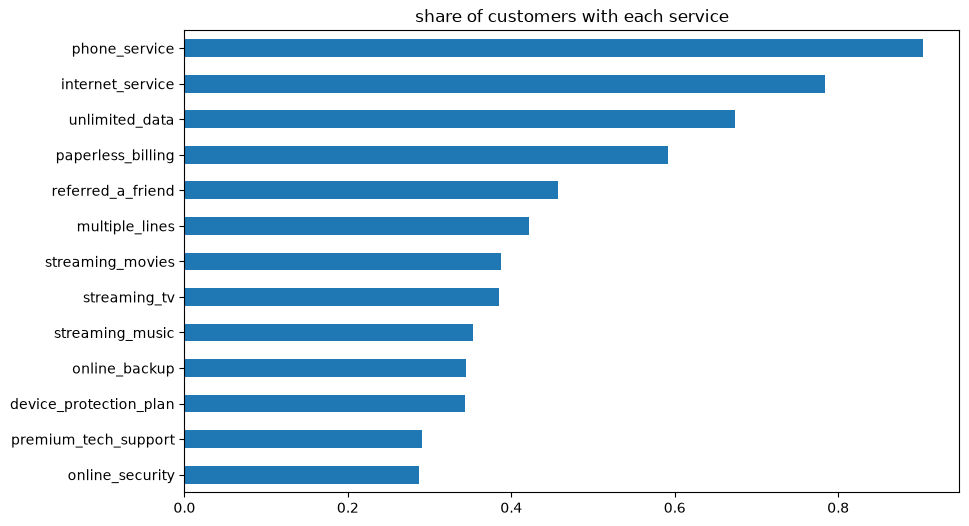

In [26]:
# take-up rate of each yes/no service flag
flags = svc_df.select_dtypes(include=["bool", "boolean"])
flags.mean().sort_values().plot(kind="barh", figsize=(10, 6), title="share of customers with each service")

In [27]:
svc_df.describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_referrals,7043.0,1.951867,3.001199,0.0,0.0,0.0,3.0,11.0
tenure_in_months,7043.0,32.386767,24.542061,1.0,9.0,29.0,55.0,72.0
avg_monthly_long_distance_charges,7043.0,22.958954,15.448113,0.0,9.21,22.89,36.395,49.99
avg_monthly_gb_download,7043.0,20.515405,20.41894,0.0,3.0,17.0,27.0,85.0
monthly_charge,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
total_charges,7043.0,2280.381264,2266.220462,18.8,400.15,1394.55,3786.6,8684.8
total_refunds,7043.0,1.962182,7.902614,0.0,0.0,0.0,0.0,49.79
total_extra_data_charges,7043.0,6.860713,25.104978,0.0,0.0,0.0,0.0,150.0
total_long_distance_charges,7043.0,749.099262,846.660055,0.0,70.545,401.44,1191.1,3564.72
total_revenue,7043.0,3034.379056,2865.204542,21.36,605.61,2108.64,4801.145,11979.34


In [44]:
# the add-ons and no-extra fee services should only be populated where the parent service exists
no_internet = svc_df[~svc_df["internet_service"]]
no_phone = svc_df[~svc_df["phone_service"]]

print("no internet, internet_type not 'none':", (no_internet["internet_type"] != "none").sum())
print("no internet, gb download > 0:", (no_internet["avg_monthly_gb_download"] > 0).sum())
print("no internet, online_security not false:", (no_internet["online_security"] != False).sum())
print("no internet, online_backup not false:", (no_internet["online_backup"] != False).sum())
print("no internet, device_protection_plan not false:", (no_internet["device_protection_plan"] != False).sum())
print("no internet, premium_tech_support not false:", (no_internet["premium_tech_support"] != False).sum())

print("no internet, streaming_tv not false:", (no_internet["streaming_tv"] != False).sum())
print("no internet, streaming_movies not false:", (no_internet["streaming_movies"] != False).sum())
print("no internet, streaming_music not false:", (no_internet["streaming_music"] != False).sum())


print("no internet, unlimited_data not false:", (no_internet["unlimited_data"] != False).sum())

print("no phone, long distance charges > 0:", (no_phone["avg_monthly_long_distance_charges"] > 0).sum())
print("no phone, multiple_lines not false:", (no_phone["multiple_lines"] > 0).sum())

no internet, internet_type not 'none': 0
no internet, gb download > 0: 0
no internet, online_security not false: 0
no internet, online_backup not false: 0
no internet, device_protection_plan not false: 0
no internet, premium_tech_support not false: 0
no internet, streaming_tv not false: 0
no internet, streaming_movies not false: 0
no internet, streaming_music not false: 0
no internet, unlimited_data not false: 0
no phone, long distance charges > 0: 0
no phone, multiple_lines not false: 0


<Axes: title={'center': 'monthly_charge'}, xlabel='contract'>

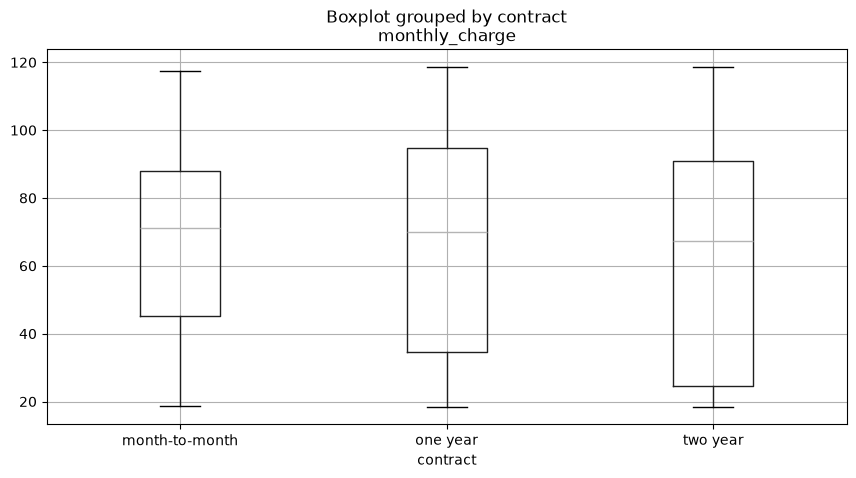

In [29]:
svc_df.boxplot(column="monthly_charge", by="contract", figsize=(10, 5))

In [30]:
# total_revenue is derived in the source - check it reconciles
recomputed = (
    svc_df["total_charges"]
    - svc_df["total_refunds"]
    + svc_df["total_extra_data_charges"]
    + svc_df["total_long_distance_charges"]
)
(svc_df["total_revenue"] - recomputed).abs().describe()

count    7043.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
dtype: Float64

### Status

In [31]:
st_df = load("stg_telco__status")
profile(st_df)

,dtype,nulls,null_pct,distinct
customer_id,str,0,0.00,7043
customer_status,str,0,0.00,3
satisfaction_score,Int64,0,0.00,5
churn_label,boolean,0,0.00,2
churn_score,Int64,0,0.00,81
cltv,Int64,0,0.00,3438
churn_reason,str,5174,73.46,20
churn_category,str,5174,73.46,5


In [32]:
print("churn rate:", st_df["churn_label"].mean().round(4))

st_df["customer_status"].value_counts(dropna=False)

churn rate: 0.2654


customer_status
stayed     4720
churned    1869
joined      454
Name: count, dtype: int64

In [33]:
# churn_reason / churn_category should only be populated for churners
print(st_df.loc[~st_df["churn_label"], ["churn_category", "churn_reason"]].notna().sum())

st_df["churn_category"].value_counts(dropna=False)

churn_category    0
churn_reason      0
dtype: int64


churn_category
NaN                5174
competitor          841
attitude            314
dissatisfaction     303
price               211
other               200
Name: count, dtype: int64

<Axes: title={'center': 'churn reasons (top 15)'}, ylabel='churn_reason'>

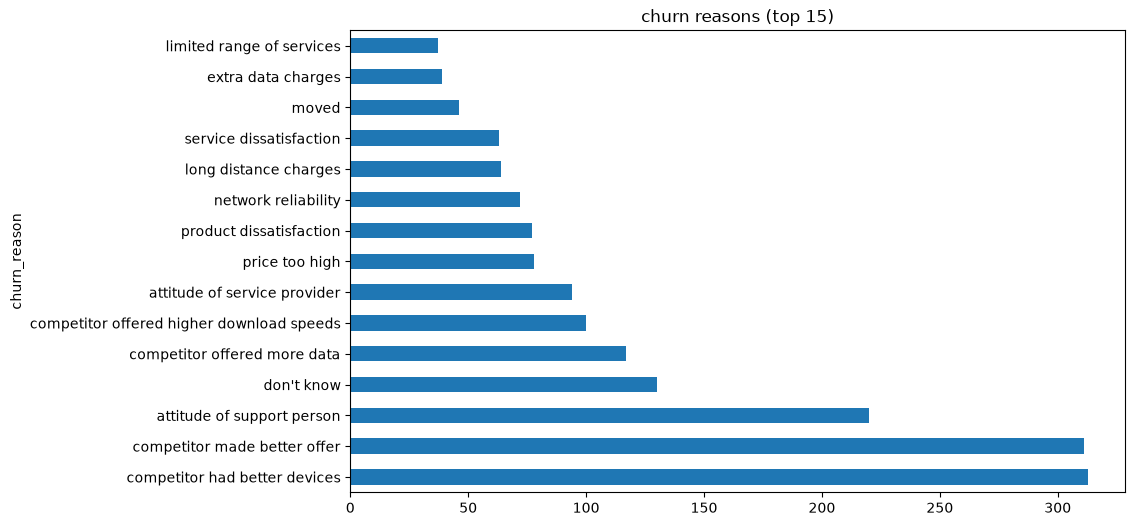

In [34]:
st_df["churn_reason"].value_counts().head(15).plot(kind="barh", figsize=(10, 6), title="churn reasons (top 15)")

In [35]:
# both are collected alongside the outcome - expect them to separate churners almost perfectly
pd.crosstab(st_df["satisfaction_score"], st_df["churn_label"], normalize="index").round(3)

churn_label,False,True
satisfaction_score,,
1,0.000,1.000
2,0.000,1.000
3,0.839,0.161
4,1.000,0.000
5,1.000,0.000


In [36]:
st_df.groupby("churn_label")["churn_score"].describe()

,count,mean,std,min,25%,50%,75%,max
churn_label,,,,,,,,
False,5174.0,50.098183,17.702277,5.0,35.0,50.0,66.0,80.0
True,1869.0,81.777956,9.16687,65.0,74.0,83.0,90.0,96.0


### Cross-table checks

In [37]:
customer_grain = {
    "demographics": demo_df,
    "location": loc_df,
    "services": svc_df,
    "status": st_df,
}

for name, df in customer_grain.items():
    print(f"{name:<13} rows={len(df):<6} unique_customer_id={df['customer_id'].nunique()}")

demographics  rows=7043   unique_customer_id=7043
location      rows=7043   unique_customer_id=7043
services      rows=7043   unique_customer_id=7043
status        rows=7043   unique_customer_id=7043


In [38]:
# the marts join these four with an inner join - confirm no customer is dropped
ids = [set(df["customer_id"]) for df in customer_grain.values()]
common = set.intersection(*ids)
union = set.union(*ids)

print("in all four:", len(common), "| in at least one:", len(union), "| dropped by the join:", len(union - common))

in all four: 7043 | in at least one: 7043 | dropped by the join: 0


### Notes

_Findings to carry into `docs/analytics_logs.md`:_

- grain confirmed / not confirmed:
- nulls worth handling:
- leakage columns (satisfaction_score, churn_score, churn_reason, churn_category):
- open questions: